In [1]:
# Numerical libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train test split
from sklearn.model_selection import train_test_split

# SVM model
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
from google.colab import files
df = files.upload()

#Read exel file
df = pd.read_csv('ML-CaseStudy2-Dataset.csv')
# Display first  rows
df.head()

Saving ML-CaseStudy2-Dataset.csv to ML-CaseStudy2-Dataset.csv


,Employee_ID,Employee_Name,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Department,City,Performance_Score,Attrition_Flag
0,11de2b9e-2148-4a1e-951b-1323d8f5f941,Austin Rodriguez,59.0,36,25860.0,11,13,6.37,sales,Pune,26.50,1
1,816703b6-7f5c-4511-8bf3-ace06d28333c,Stephanie Salazar,31.0,4,69131.0,11,8,6.86,IT,Mumbai,43.23,1
2,d10e1435-380e-4727-bab0-d1db39ea5e9e,Mrs. Jaclyn Chavez,22.0,0,87955.0,9,2,2.64,Human Resource,Mumbai,43.28,1
3,d8456859-9280-4bb0-a772-78952813e838,Susan Quinn,42.0,14,131970.0,13,12,9.76,sales,Chennai,77.60,1
4,791f7234-a526-4b85-adaa-70b4b01cbad8,Matthew Nelson,35.0,13,92435.0,10,4,6.33,sales,Hyderabad,58.22,0


In [4]:
# Shape of dataset
print(df.shape)

# Column names
print(df.columns)

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

(5050, 12)
Index(['Employee_ID', 'Employee_Name', 'Age', 'Years_of_Experience',
       'Monthly_Salary', 'Working_Hours_Per_Day', 'Projects_Handled',
       'Job_Satisfaction', 'Department', 'City', 'Performance_Score',
       'Attrition_Flag'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            5050 non-null   object 
 1   Employee_Name          5050 non-null   object 
 2   Age                    4950 non-null   float64
 3   Years_of_Experience    5050 non-null   int64  
 4   Monthly_Salary         4949 non-null   float64
 5   Working_Hours_Per_Day  5050 non-null   int64  
 6   Projects_Handled       5050 non-null   int64  
 7   Job_Satisfaction       4949 non-null   float64
 8   Department             5050 non-null   object 
 9   City                   5050 non-null   object 
 

In [3]:
# Check null values
print(df.isnull().sum())

Employee_ID                0
Employee_Name              0
Age                      100
Years_of_Experience        0
Monthly_Salary           101
Working_Hours_Per_Day      0
Projects_Handled           0
Job_Satisfaction         101
Department                 0
City                       0
Performance_Score          0
Attrition_Flag             0
dtype: int64


In [5]:
df.duplicated().any()

np.True_

In [6]:
df.duplicated().sum()

np.int64(46)

In [7]:
df[df.duplicated()]

,Employee_ID,Employee_Name,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Department,City,Performance_Score,Attrition_Flag
5000,8db8a8a9-44b3-4885-84b2-9c1e88f4aa5a,Scott Schwartz,48.0,19,57009.0,7,7,2.93,Finance,Mumbai,34.21,1
5001,936d5774-9919-4056-b248-2c4c58d4f683,Shelby Garcia,37.0,10,45543.0,13,12,6.03,marketing,Mumbai,25.11,1
5002,89f60d5a-db33-47ce-8157-427ad3e2937c,Ann Griffin,21.0,0,140749.0,9,13,2.24,marketing,Chennai,65.38,1
5003,1c64a810-2b94-4ef5-96ba-e13f53e9368f,Keith Padilla,45.0,22,148721.0,13,8,9.54,marketing,Hyderabad,104.63,1
5004,5bb73a9d-a788-4bb9-80ba-9b9987b1c09e,Cody Thompson,46.0,18,138985.0,11,9,5.19,Human Resource,Delhi,86.73,1
5005,16529f4a-023f-479a-b1ef-37f0aa0a1a00,Alicia Simpson,55.0,32,25302.0,11,6,3.13,marketing,Mumbai,25.71,1
5006,dcd1323d-a7e7-4153-bd69-3b63b73d7607,Jamie Burns,31.0,7,95130.0,9,11,1.12,Marketing,Pune,48.32,1
5007,5dd58345-0725-4df5-b2cf-d0a41c702383,Amber Avila,34.0,12,130327.0,13,1,1.04,marketing,Mumbai,77.17,1
5008,186aa530-9807-42a8-aff0-7d8a54601d75,Jacqueline Brooks,43.0,23,116411.0,12,10,1.31,Marketing,Mumbai,71.21,1
5009,44567183-d116-43ae-9131-d5a8ad7032bb,Jody Green,48.0,22,134743.0,6,10,8.18,Marketing,Pune,86.93,0


In [8]:
data1 = df.drop_duplicates()

In [9]:
df.duplicated().any()

np.True_

In [10]:
data1.shape

(5004, 12)

In [11]:
#Indexing columns
df = data1.isnull().sum().reset_index()
#Rename column
df.columns = ['column', 'null_records']
#Create new colums and Find out null value percentage
df['% null records'] = (df['null_records']/5050)*100
df

,column,null_records,% null records
0,Employee_ID,0,0.000000
1,Employee_Name,0,0.000000
2,Age,100,1.980198
3,Years_of_Experience,0,0.000000
4,Monthly_Salary,100,1.980198
5,Working_Hours_Per_Day,0,0.000000
6,Projects_Handled,0,0.000000
7,Job_Satisfaction,100,1.980198
8,Department,0,0.000000
9,City,0,0.000000


In [ ]:
 data1.columns.str.strip()

Index(['Employee_ID', 'Employee_Name', 'Age', 'Years_of_Experience',
       'Monthly_Salary', 'Working_Hours_Per_Day', 'Projects_Handled',
       'Job_Satisfaction', 'Department', 'City', 'Performance_Score',
       'Attrition_Flag'],
      dtype='object')

In [ ]:
print(data1.columns)

Index(['Employee_ID', 'Employee_Name', 'Age', 'Years_of_Experience',
       'Monthly_Salary', 'Working_Hours_Per_Day', 'Projects_Handled',
       'Job_Satisfaction', 'Department', 'City', 'Performance_Score',
       'Attrition_Flag'],
      dtype='object')


In [13]:
Age_mean = data1['Age'].mean()
Age_mean
data1['Age'] = data1['Age'].fillna(Age_mean)

In [14]:
Monthly_Salary_mean = data1['Monthly_Salary'].mean()
Monthly_Salary_mean
data1['Monthly_Salary'] = data1['Monthly_Salary'].fillna(Monthly_Salary_mean)

In [15]:
Job_Satisfaction_mean = data1['Job_Satisfaction'].mean()
Job_Satisfaction_mean
data1['Job_Satisfaction'] = data1['Job_Satisfaction'].fillna(Job_Satisfaction_mean)

In [16]:
data1.isnull().sum()

,0
Employee_ID,0
Employee_Name,0
Age,0
Years_of_Experience,0
Monthly_Salary,0
Working_Hours_Per_Day,0
Projects_Handled,0
Job_Satisfaction,0
Department,0
City,0


In [17]:
print(data1.columns)

Index(['Employee_ID', 'Employee_Name', 'Age', 'Years_of_Experience',
       'Monthly_Salary', 'Working_Hours_Per_Day', 'Projects_Handled',
       'Job_Satisfaction', 'Department', 'City', 'Performance_Score',
       'Attrition_Flag'],
      dtype='object')


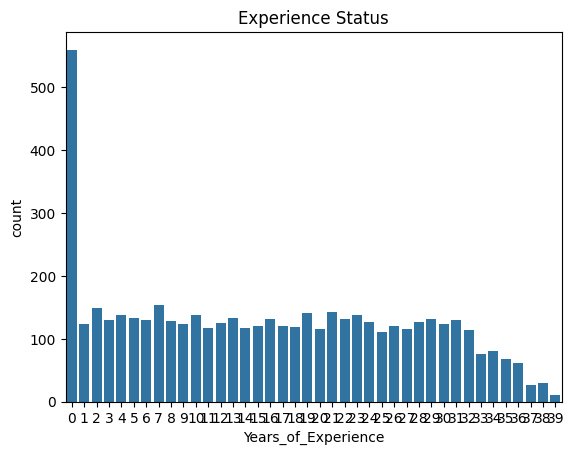

In [18]:
sns.countplot(x='Years_of_Experience', data=data1)

plt.title("Experience Status")

plt.show()

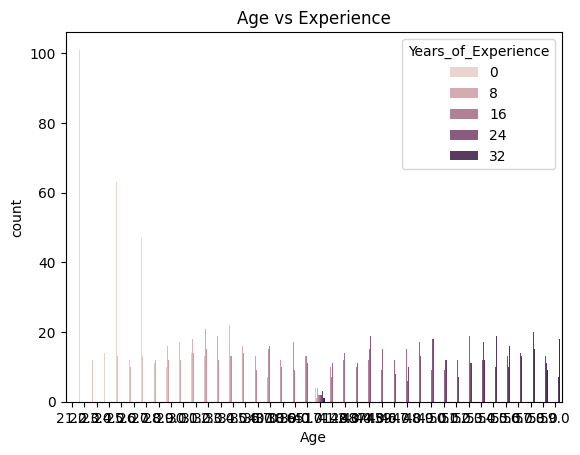

In [19]:
sns.countplot(x='Age',
              hue='Years_of_Experience',
              data=data1)

plt.title("Age vs Experience")

plt.show()

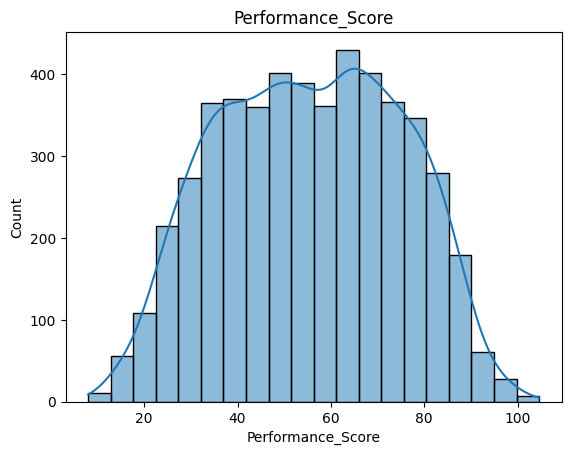

In [20]:
sns.histplot(data1['Performance_Score'],
             bins=20,
             kde=True)

plt.title("Performance_Score")

plt.show()

In [25]:
Categorical_col = data1.select_dtypes(include = 'object').columns
Categorical_col

Index(['Employee_ID', 'Employee_Name', 'Department', 'City'], dtype='object')

In [26]:
le = LabelEncoder()

data1['Employee_ID'] = le.fit_transform(data1['Employee_ID'])

data1['Employee_Name'] = le.fit_transform(data1['Employee_Name'])

data1['Department'] = le.fit_transform(data1['Department'])

data1['City'] = le.fit_transform(data1['City'])

**Objective:**
To classify Attrition_Flag by finding the optimal boundary that separates employees who leave from those who stay.

In [27]:
X = data1.drop('Attrition_Flag', axis=1)
y = data1['Attrition_Flag']


In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

svm_model = SVC(
    kernel='linear',
    C=1
)

svm_model.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [29]:
y_pred = svm_model.predict(X_test)

print(y_pred)

[1 1 1 ... 1 0 1]


In [30]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8301698301698301


[[326 103]
 [ 67 505]]


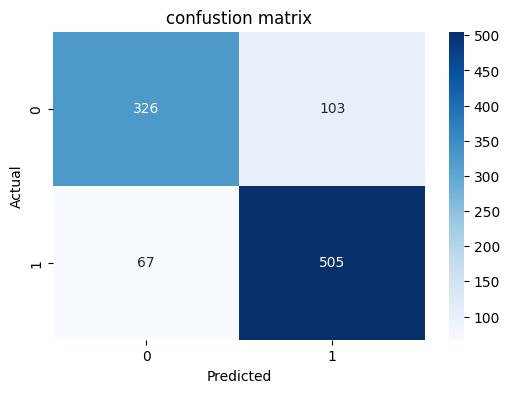

In [36]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("confustion matrix")
plt.show()

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.76      0.79       429
           1       0.83      0.88      0.86       572

    accuracy                           0.83      1001
   macro avg       0.83      0.82      0.82      1001
weighted avg       0.83      0.83      0.83      1001



In [33]:
svm_rbf = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

svm_rbf.fit(X_train, y_train)

rbf_pred = svm_rbf.predict(X_test)

print("RBF Accuracy:",
      accuracy_score(y_test, rbf_pred))

RBF Accuracy: 0.9370629370629371


In [35]:
svm_rbf.fit(X_train, y_train)

rbf_pred = svm_rbf.predict(X_test)

print("RBF Accuracy:",
      accuracy_score(y_test, rbf_pred))

svm_poly = SVC(
    kernel='poly',
    degree=3
)

svm_poly.fit(X_train, y_train)

poly_pred = svm_poly.predict(X_test)

print("Polynomial Accuracy:",
      accuracy_score(y_test, poly_pred))

RBF Accuracy: 0.9370629370629371
Polynomial Accuracy: 0.8211788211788211


**Conclusion**

Support Vector Machine (SVM) was applied to classify employee attrition using features such as Age, Years_of_Experience, Monthly_Salary, Working_Hours_Per_Day, Projects_Handled, Job_Satisfaction, Department, and City. Different SVM kernels were tested to evaluate classification performance.

The Linear SVM model achieved an accuracy of approximately 83.02%, showing good performance in predicting employee attrition. The RBF kernel produced the highest accuracy of 93.71%, indicating superior classification capability and better handling of complex and non-linear patterns in the dataset. The Polynomial kernel achieved an accuracy of 82.12%, which was comparatively lower than the RBF kernel.

The classification report further showed balanced precision, recall, and F1-scores, demonstrating reliable prediction for both attrition classes. Overall, the RBF kernel-based SVM proved to be the most effective model for employee attrition classification in this dataset and can be considered a strong approach for workforce attrition prediction.